# BP-SNN MNIST 2-Layer Results: Scientific Report

This notebook creates publication-style figures for BP runs under `./result/2layers/`.

Outputs are saved to `./result/2layers/visualizations/`.

In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

MODELS = ['lif', 'alif', 'srm', 'dynsrm']
MODEL_COLORS = {'lif':'#1f77b4','alif':'#2ca02c','srm':'#d62728','dynsrm':'#9467bd'}

In [2]:
root = Path.cwd()
results_dir = root / 'result' / '2layers'
viz_dir = results_dir / 'visualizations'
viz_dir.mkdir(parents=True, exist_ok=True)

csv_files = sorted(results_dir.glob('**/MNIST_*_BP_v2_*.csv'))
summary_files = sorted(results_dir.glob('**/MNIST_*_BP_v2_*_summary.json'))

print(f'Found {len(csv_files)} csv files')
print(f'Found {len(summary_files)} summary files')

def extract_model_and_runid(path: Path):
    m = re.search(r'MNIST_(?P<model>[^_]+)_BP_v2_(?P<rid>\d{8}_\d{6})', path.name)
    if not m:
        return None, None
    return m.group('model'), m.group('rid')

# keep latest run per model
latest_csv = {}
for p in csv_files:
    model, rid = extract_model_and_runid(p)
    if model not in MODELS or rid is None:
        continue
    if model not in latest_csv or rid > latest_csv[model][0]:
        latest_csv[model] = (rid, p)

runs = {}
for model in MODELS:
    if model in latest_csv:
        rid, p = latest_csv[model]
        df = pd.read_csv(p)
        runs[model] = {'run_id': rid, 'csv_path': p, 'df': df}

print('Selected latest runs:')
for m in runs:
    print(f'  {m:7s} -> {runs[m]["run_id"]} | {runs[m]["csv_path"].name}')

Found 14 csv files
Found 4 summary files
Selected latest runs:
  lif     -> 20260408_003530 | MNIST_lif_BP_v2_20260408_003530.csv
  alif    -> 20260408_003712 | MNIST_alif_BP_v2_20260408_003712.csv
  srm     -> 20260408_003805 | MNIST_srm_BP_v2_20260408_003805.csv
  dynsrm  -> 20260408_003907 | MNIST_dynsrm_BP_v2_20260408_003907.csv


In [3]:
records = []
for model, pack in runs.items():
    df = pack['df']
    if df.empty:
        continue
    best_idx = df['test_acc'].idxmax() if 'test_acc' in df.columns else df.index[-1]
    last = df.iloc[-1]
    best = df.loc[best_idx]
    rec = {
        'model': model,
        'epochs': int(df['epoch'].max()) if 'epoch' in df.columns else len(df),
        'best_test_acc': float(best.get('test_acc', np.nan)),
        'best_test_f1': float(best.get('test_macro_f1', np.nan)),
        'final_test_acc': float(last.get('test_acc', np.nan)),
        'final_test_f1': float(last.get('test_macro_f1', np.nan)),
        'final_test_speed': float(last.get('test_speed', np.nan)),
        'final_test_latency_ms': float(last.get('test_latency_ms_per_sample', np.nan)),
        'final_test_cpu_mem_mb': float(last.get('test_cpu_memory_mb', np.nan)),
        'final_test_gpu_mem_mb': float(last.get('test_gpu_memory_allocated_mb', np.nan)),
        'final_test_spike_rate': float(last.get('test_global_spike_rate', np.nan)),
        'final_test_event_dense_ratio': float(last.get('test_event_to_dense_ratio', np.nan)),
    }
    records.append(rec)

summary_df = pd.DataFrame(records).sort_values('best_test_acc', ascending=False)
summary_df

,model,epochs,best_test_acc,best_test_f1,final_test_acc,final_test_f1,final_test_speed,final_test_latency_ms,final_test_cpu_mem_mb,final_test_gpu_mem_mb,final_test_spike_rate,final_test_event_dense_ratio
3,dynsrm,100,0.9849,0.984759,0.9845,0.984386,2083.819204,0.479888,1444.234375,127.025879,0.194850,0.192808
2,srm,100,0.9836,0.983505,0.9827,0.982524,2710.472587,0.368939,1410.820312,127.016113,0.197367,0.192840
1,alif,100,0.9828,0.982652,0.9800,0.979908,2234.661564,0.447495,1461.578125,127.020020,0.183402,0.192661
0,lif,100,0.9805,0.980323,0.9773,0.977188,1856.789405,0.538564,1453.429688,127.016113,0.170128,0.192490


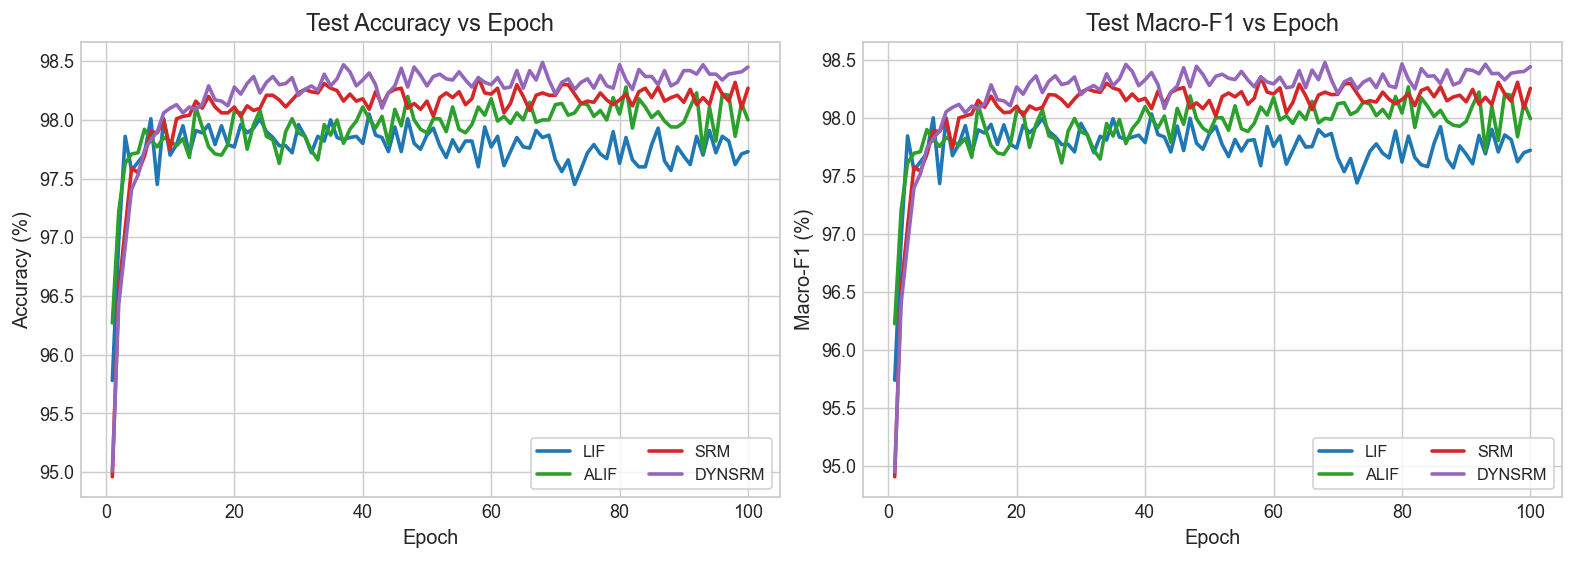

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/visualizations/curve_accuracy_f1.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), constrained_layout=True)

for model, pack in runs.items():
    df = pack['df']
    c = MODEL_COLORS[model]
    if {'epoch','test_acc'}.issubset(df.columns):
        axes[0].plot(df['epoch'], 100.0*df['test_acc'], label=model.upper(), color=c, lw=2)
    if {'epoch','test_macro_f1'}.issubset(df.columns):
        axes[1].plot(df['epoch'], 100.0*df['test_macro_f1'], label=model.upper(), color=c, lw=2)

axes[0].set_title('Test Accuracy vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(frameon=True, ncol=2)

axes[1].set_title('Test Macro-F1 vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro-F1 (%)')
axes[1].legend(frameon=True, ncol=2)

out_path = viz_dir / 'curve_accuracy_f1.png'
fig.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

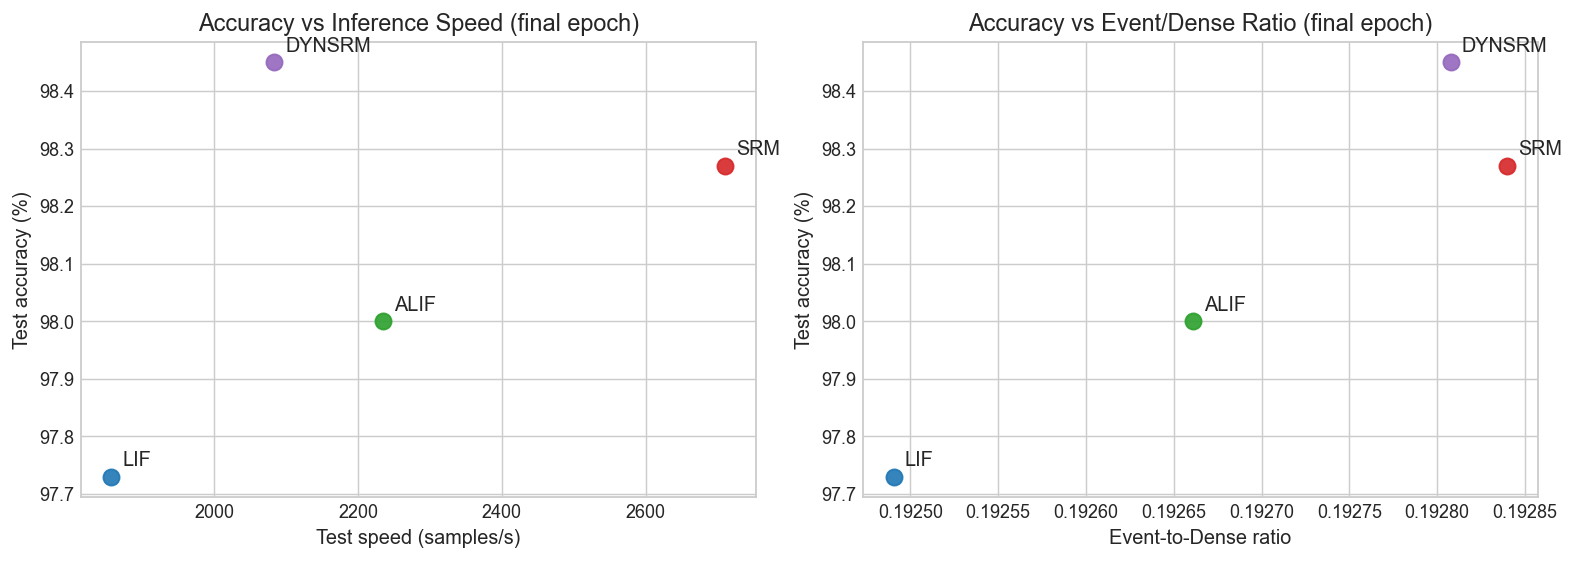

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/visualizations/tradeoff_speed_energy_accuracy.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), constrained_layout=True)

for model, pack in runs.items():
    df = pack['df']
    if df.empty:
        continue
    last = df.iloc[-1]
    c = MODEL_COLORS[model]
    x_speed = float(last.get('test_speed', np.nan))
    y_acc = 100.0 * float(last.get('test_acc', np.nan))
    mem = float(last.get('test_gpu_memory_allocated_mb', np.nan))
    ratio = float(last.get('test_event_to_dense_ratio', np.nan))

    axes[0].scatter(x_speed, y_acc, s=80, color=c, alpha=0.9)
    axes[0].annotate(model.upper(), (x_speed, y_acc), xytext=(6,6), textcoords='offset points')

    axes[1].scatter(ratio, y_acc, s=80, color=c, alpha=0.9)
    axes[1].annotate(model.upper(), (ratio, y_acc), xytext=(6,6), textcoords='offset points')

axes[0].set_title('Accuracy vs Inference Speed (final epoch)')
axes[0].set_xlabel('Test speed (samples/s)')
axes[0].set_ylabel('Test accuracy (%)')

axes[1].set_title('Accuracy vs Event/Dense Ratio (final epoch)')
axes[1].set_xlabel('Event-to-Dense ratio')
axes[1].set_ylabel('Test accuracy (%)')

out_path = viz_dir / 'tradeoff_speed_energy_accuracy.png'
fig.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

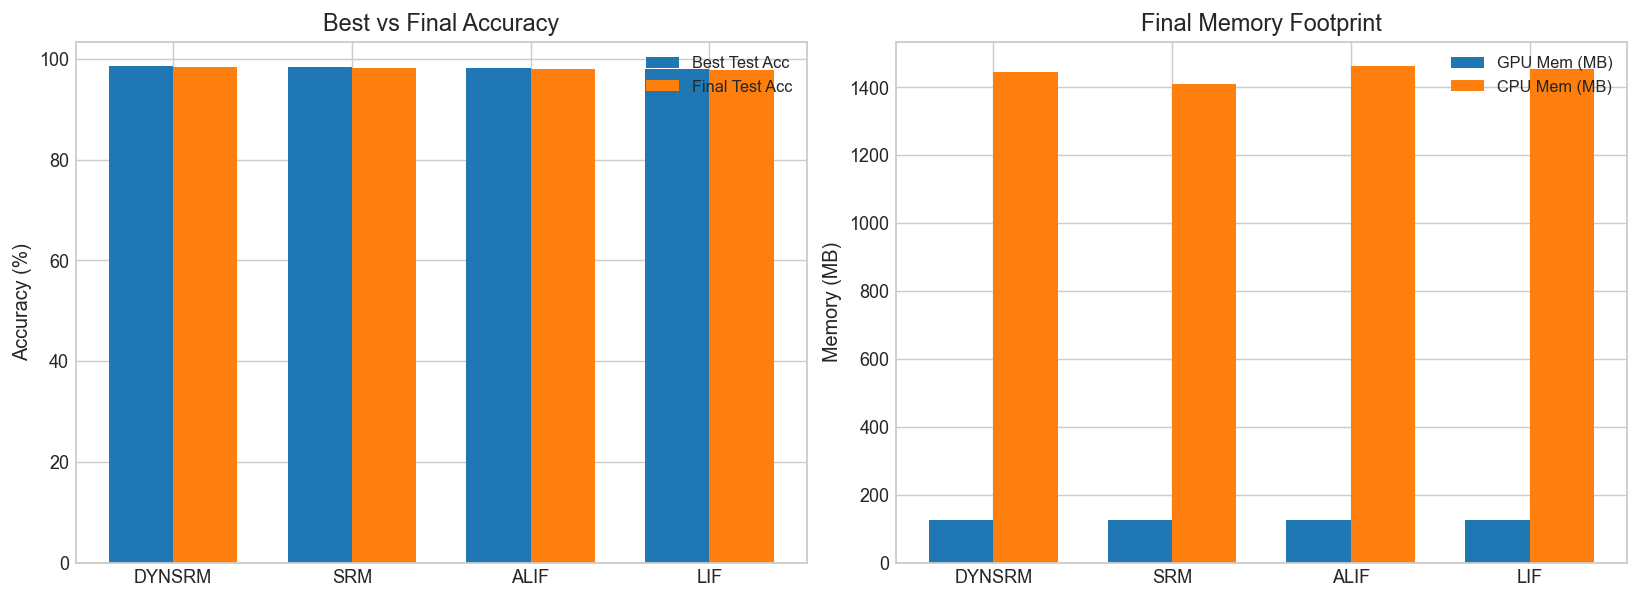

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/visualizations/bar_accuracy_memory.png


In [6]:
if not summary_df.empty:
    plot_df = summary_df.set_index('model')
    models = list(plot_df.index)
    x = np.arange(len(models))
    w = 0.36

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5), constrained_layout=True)

    axes[0].bar(x - w/2, 100*plot_df['best_test_acc'], width=w, label='Best Test Acc')
    axes[0].bar(x + w/2, 100*plot_df['final_test_acc'], width=w, label='Final Test Acc')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([m.upper() for m in models])
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('Best vs Final Accuracy')
    axes[0].legend()

    axes[1].bar(x - w/2, plot_df['final_test_gpu_mem_mb'], width=w, label='GPU Mem (MB)')
    axes[1].bar(x + w/2, plot_df['final_test_cpu_mem_mb'], width=w, label='CPU Mem (MB)')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([m.upper() for m in models])
    axes[1].set_ylabel('Memory (MB)')
    axes[1].set_title('Final Memory Footprint')
    axes[1].legend()

    out_path = viz_dir / 'bar_accuracy_memory.png'
    fig.savefig(out_path, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_path}')

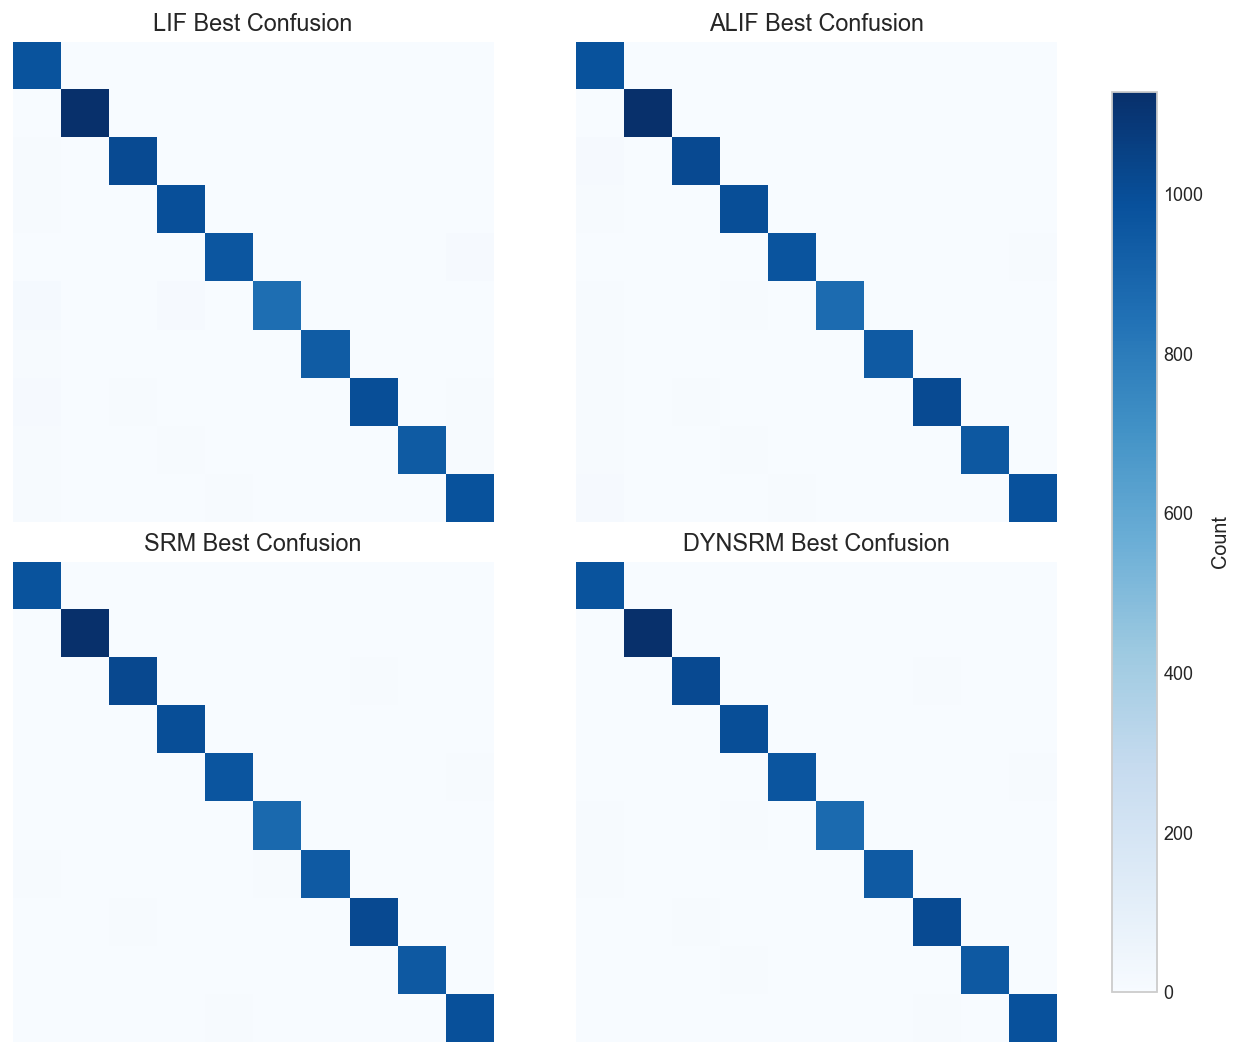

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/visualizations/confusion_matrices_best.png


In [7]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
axs = axs.ravel()

for ax in axs:
    ax.axis('off')

for i, model in enumerate(MODELS):
    if model not in runs:
        continue
    csv_path = runs[model]['csv_path']
    cm_path = csv_path.with_name(csv_path.name.replace('.csv', '_best_test_confusion.csv'))
    if not cm_path.exists():
        continue
    cm = pd.read_csv(cm_path, index_col=0).values
    ax = axs[i]
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{model.upper()} Best Confusion')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))

cbar = fig.colorbar(im, ax=axs.tolist(), shrink=0.9)
cbar.set_label('Count')
out_path = viz_dir / 'confusion_matrices_best.png'
fig.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

In [8]:
summary_out = viz_dir / 'summary_table.csv'
summary_df.to_csv(summary_out, index=False)
print('Saved summary table:', summary_out)
summary_df

Saved summary table: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/MNIST/v2/result/2layers/visualizations/summary_table.csv


,model,epochs,best_test_acc,best_test_f1,final_test_acc,final_test_f1,final_test_speed,final_test_latency_ms,final_test_cpu_mem_mb,final_test_gpu_mem_mb,final_test_spike_rate,final_test_event_dense_ratio
3,dynsrm,100,0.9849,0.984759,0.9845,0.984386,2083.819204,0.479888,1444.234375,127.025879,0.194850,0.192808
2,srm,100,0.9836,0.983505,0.9827,0.982524,2710.472587,0.368939,1410.820312,127.016113,0.197367,0.192840
1,alif,100,0.9828,0.982652,0.9800,0.979908,2234.661564,0.447495,1461.578125,127.020020,0.183402,0.192661
0,lif,100,0.9805,0.980323,0.9773,0.977188,1856.789405,0.538564,1453.429688,127.016113,0.170128,0.192490
